# 301a — Individual parameter known-error analysis for depletion_q

This notebook holds the validated baseline `depletion_q` Pareto designs fixed and re-evaluates those same pumping designs under known one-parameter perturbations.

Currently supported parameters:

- `transmissivity` using `project_properties.T`
- `storage` using `project_properties.S`

This is now named `301a` because `301b` handles combined T/S scenarios.

Main question:

> If the pumping plan was optimized assuming the baseline parameter value, what happens if the true value of one parameter is actually lower or higher?


## 1. Imports, helper reload, and user controls

To run storage, set `PARAMETER_TO_RUN = "storage"`.

To rerun transmissivity, set `PARAMETER_TO_RUN = "transmissivity"`.

Important cache note: if you first ran a small sample using `N_TEST_MEMBERS = 10`, then switch to `N_TEST_MEMBERS = None`, use `RERUN_REEVALUATION = True` for the full run so the cache is overwritten with the complete Pareto front.


In [ ]:
from pathlib import Path
import sys
import importlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

# Force Jupyter to reload the local helper file instead of using a stale import.
sys.modules.pop("uncertainty_project_helpers_depletion_q", None)
importlib.invalidate_caches()
import uncertainty_project_helpers_depletion_q as up

print("Helper imported from:", up.__file__)
print("Helper version:", up.HELPER_VERSION)

PROJECT_DIR = up.find_lpr_pycap_opt_dir()
NOTEBOOK_DIR = PROJECT_DIR / "notebooks" / "Uncertainty_Project_depletion_q"
CACHE_DIR = NOTEBOOK_DIR / "cached_reevaluations"

# -----------------------------------------------------------------------------
# User controls
# -----------------------------------------------------------------------------
RUN_NAME = "depletion_q_baseline_0.0_1.0_0.01"

# Supported: "transmissivity" or "storage".
PARAMETER_TO_RUN = "transmissivity"
PARAMETER_CONFIG = up.get_parameter_config(PARAMETER_TO_RUN)
PARAMETER_OUTPUT_TAG = PARAMETER_CONFIG["scenario_tag"]
PARAMETER_LABEL = PARAMETER_CONFIG["label"]
PARAMETER_SYMBOL = PARAMETER_CONFIG["symbol"]

# Known-error factors. For storage, this means S -10%, baseline S, and S +10%.
PARAMETER_FACTORS = [0.9, 1.0, 1.1]

# Set True when you want to run PyCap again. Set False after the full cache exists.
RERUN_REEVALUATION = False

# Use a small integer like 5 or 10 for a quick test. Use None for the full Pareto front.
N_TEST_MEMBERS = None

OUTPUT_DIR = NOTEBOOK_DIR / "project_output" / "301a_individual_parameter_known_error_depletion_q" / PARAMETER_OUTPUT_TAG
CACHE_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

CACHE_FILE = CACHE_DIR / f"301a_depletion_q_{PARAMETER_OUTPUT_TAG}_scenario_reevaluation_v1.csv"
ERROR_CACHE_FILE = CACHE_DIR / f"301a_depletion_q_{PARAMETER_OUTPUT_TAG}_scenario_reevaluation_errors_v1.csv"

up.apply_plot_style()

print("PROJECT_DIR:", PROJECT_DIR)
print("OUTPUT_DIR:", OUTPUT_DIR)
print("CACHE_FILE:", CACHE_FILE)
print("PARAMETER_TO_RUN:", PARAMETER_TO_RUN)
print("PARAMETER_FACTORS:", PARAMETER_FACTORS)
print("RERUN_REEVALUATION:", RERUN_REEVALUATION)
print("N_TEST_MEMBERS:", N_TEST_MEMBERS)


Helper imported from: /workspaces/LPR_redux/LPR_pycap_opt/notebooks/Uncertainty_Project_depletion_q/uncertainty_project_helpers_depletion_q.py
Helper version: 2026-05-23_depletion_q_304_v2_clean_member_labels_and_reliability_plot
PROJECT_DIR: /workspaces/LPR_redux/LPR_pycap_opt
OUTPUT_DIR: /workspaces/LPR_redux/LPR_pycap_opt/notebooks/Uncertainty_Project_depletion_q/project_output/301a_individual_parameter_known_error_depletion_q/storage
CACHE_FILE: /workspaces/LPR_redux/LPR_pycap_opt/notebooks/Uncertainty_Project_depletion_q/cached_reevaluations/301a_depletion_q_storage_scenario_reevaluation_v1.csv
PARAMETER_TO_RUN: storage
PARAMETER_FACTORS: [0.9, 1.0, 1.1]
RERUN_REEVALUATION: False
N_TEST_MEMBERS: None


## 2. Load the depletion_q baseline model context and Pareto design population

This loads the original `depletion_q` run, selects the final feasible front, and loads the decision-variable population.

For `depletion_q`, the pumping objective is the sum of the PEST decision-variable pumping parameters, not necessarily the sum of every pumping entry in the forward model.


In [9]:
context = up.load_depletion_q_context(RUN_NAME, project_dir=PROJECT_DIR)
archive = up.read_pareto_archive_summary(RUN_NAME, context.run_dir)
pareto_final = up.select_final_feasible_front1(archive)
dv_df = up.load_decision_variable_population(context.run_dir)

if N_TEST_MEMBERS is not None:
    pareto_final = pareto_final.head(int(N_TEST_MEMBERS)).copy()

all_q_cols = up.get_q_columns(dv_df)
base_parameter_value = up.get_project_parameter_value(context.initial_dict_master, PARAMETER_TO_RUN)

print("Run directory:", context.run_dir)
print("Base T:", up.get_project_parameter_value(context.initial_dict_master, "transmissivity"))
print("Base S:", up.get_project_parameter_value(context.initial_dict_master, "storage"))
print("Parameter being tested:", PARAMETER_LABEL)
print("Base parameter value:", base_parameter_value)
print("Number of final front members selected:", len(pareto_final))
print("Decision-variable population shape:", dv_df.shape)
print("Number of all pumping columns in dv_df:", len(all_q_cols))
print("Number of decision-variable pumping columns from PEST control file:", len(context.decvar_q_cols))

display(pareto_final[["member", "generation", "obj_well", up.DEPLETION_OBS_NAME]].head())
display(dv_df.head())


Run directory: /workspaces/LPR_redux/LPR_pycap_opt/pycap_runs/pycap_pest/run_depletion_q_baseline_0.0_1.0_0.01
Base T: 1700.0
Base S: 0.12
Parameter being tested: Storage
Base parameter value: 0.12
Number of final front members selected: 296
Decision-variable population shape: (8772, 327)
Number of all pumping columns in dv_df: 327
Number of decision-variable pumping columns from PEST control file: 86


,member,generation,obj_well,lpr:total_combined:bdpl
8495,152,50,17542.80,4.782580
8496,gen=36_member=6021_pso,50,7060.34,0.811083
8497,16,50,17265.50,4.489270
8498,130,50,17325.00,4.690710
8499,95,50,17459.90,4.701270


,well_1013__q,well_1302__q,well_1323__q,well_1486__q,well_1584__q,well_1589__q,well_1643__q,well_1683__q,well_1860__q,well_23610__q,...,well_93143__q,well_93349__q,well_93422__q,well_93423__q,well_93424__q,well_93469__q,well_93832__q,well_94302__q,well_94988__q,well_95068__q
68,125.1,88.2,76.2,195.670613,137.952010,264.1,114.5,260.6,195.7,231.977419,...,0.578136,27.2,0.1,0.1,0.2,163.452296,14.6,143.870904,11.1,40.3
152,125.1,88.2,76.2,263.694528,134.751495,264.1,114.5,260.6,195.7,212.789243,...,0.643249,27.2,0.1,0.1,0.2,188.927899,14.6,171.709627,11.1,40.3
16,125.1,88.2,76.2,200.682701,170.213382,264.1,114.5,260.6,195.7,190.889313,...,0.702573,27.2,0.1,0.1,0.2,145.038900,14.6,153.466090,11.1,40.3
130,125.1,88.2,76.2,265.956362,144.227698,264.1,114.5,260.6,195.7,218.143802,...,0.635653,27.2,0.1,0.1,0.2,171.823604,14.6,133.683458,11.1,40.3
95,125.1,88.2,76.2,208.937516,136.708745,264.1,114.5,260.6,195.7,204.507103,...,0.694806,27.2,0.1,0.1,0.2,182.539445,14.6,153.717470,11.1,40.3


## 3. Re-evaluate the fixed baseline designs under known parameter scenarios

For the current run, the scenarios are:

- parameter -10%
- baseline parameter
- parameter +10%

The cache guard checks that the cached result has the expected number of rows. This prevents accidentally using a small test cache when `N_TEST_MEMBERS` has been changed back to `None`.


In [10]:
SCENARIOS = up.make_known_parameter_scenario_dict(
    parameter_name=PARAMETER_TO_RUN,
    base_value=base_parameter_value,
    factors=PARAMETER_FACTORS,
)
scenario_order = list(SCENARIOS.keys())
baseline_scenario = [s for s in scenario_order if s.startswith("baseline")][0]
expected_rows = len(pareto_final) * len(SCENARIOS)

print("Scenarios:", SCENARIOS)
print("Baseline scenario:", baseline_scenario)
print("Expected rows:", expected_rows)

if RERUN_REEVALUATION or not CACHE_FILE.exists():
    results_long, error_df = up.reevaluate_depletion_q_designs(
        pareto_final=pareto_final,
        dv_df=dv_df,
        q_cols=all_q_cols,
        context=context,
        scenarios=SCENARIOS,
        progress_every=50,
    )
    results_long.to_csv(CACHE_FILE, index=False)
    up.write_error_cache(error_df, ERROR_CACHE_FILE)
else:
    results_long = pd.read_csv(CACHE_FILE)
    error_df = up.read_csv_if_not_empty(ERROR_CACHE_FILE)

if len(results_long) != expected_rows:
    raise ValueError(f"Cached or generated result has {len(results_long)} rows, but {expected_rows} rows were expected. Set RERUN_REEVALUATION = True to rebuild the cache for the current N_TEST_MEMBERS setting.")

print("Re-evaluation rows:", len(results_long))
print("Error rows:", len(error_df))
if not error_df.empty:
    display(error_df.head())

print("Available result scenarios:", sorted(results_long["scenario"].dropna().unique()))
baseline_scenario = up._resolve_baseline_scenario(results_long, baseline_scenario)
scenario_order = up._resolve_scenario_order(results_long, scenario_order)
print("Resolved baseline scenario:", baseline_scenario)
print("Resolved scenario order:", scenario_order)

display(results_long.head())


Scenarios: {'storage_minus_10pct': {'parameter_name': 'storage', 'parameter_label': 'Storage', 'parameter_factor': 0.9, 'parameter_value': 0.108}, 'baseline_storage': {'parameter_name': 'storage', 'parameter_label': 'Storage', 'parameter_factor': 1.0, 'parameter_value': 0.12}, 'storage_plus_10pct': {'parameter_name': 'storage', 'parameter_label': 'Storage', 'parameter_factor': 1.1, 'parameter_value': 0.132}}
Baseline scenario: baseline_storage
Expected rows: 888
Re-evaluation rows: 888
Error rows: 0
Available result scenarios: ['baseline_storage', 'storage_minus_10pct', 'storage_plus_10pct']
Resolved baseline scenario: baseline_storage
Resolved scenario order: ['storage_minus_10pct', 'baseline_storage', 'storage_plus_10pct']


,member,generation,scenario,parameter_name,parameter_label,parameter_symbol,parameter_factor,parameter_value,base_parameter_value,probability_weight,T_factor,T_value,S_factor,S_value,archive_pumping_objective_cfs,pumping_objective_reeval_cfs,full_model_total_pumping_cfs,archive_depletion_cfs,depletion_cfs,streamflow_cfs
0,152,50,storage_minus_10pct,storage,Storage,S,0.9,0.108,0.12,NaN,NaN,NaN,0.9,0.108,39.085358,39.085441,117.697971,4.782580,5.043316,3.556684
1,gen=36_member=6021_pso,50,storage_minus_10pct,storage,Storage,S,0.9,0.108,0.12,NaN,NaN,NaN,0.9,0.108,15.730438,15.730429,94.342958,0.811083,0.890253,7.709747
2,16,50,storage_minus_10pct,storage,Storage,S,0.9,0.108,0.12,NaN,NaN,NaN,0.9,0.108,38.467534,38.467529,117.080058,4.489270,4.741138,3.858862
3,130,50,storage_minus_10pct,storage,Storage,S,0.9,0.108,0.12,NaN,NaN,NaN,0.9,0.108,38.600100,38.600146,117.212675,4.690710,4.947701,3.652299
4,95,50,storage_minus_10pct,storage,Storage,S,0.9,0.108,0.12,NaN,NaN,NaN,0.9,0.108,38.900657,38.900681,117.513211,4.701270,4.961543,3.638457


## 4. Create wide and summary tables

These tables are saved with the parameter name in the filename.


In [11]:
results_long_with_errors = up.add_known_parameter_error_columns(
    results_long,
    baseline_scenario=baseline_scenario,
)
baseline_scenario = up._resolve_baseline_scenario(results_long_with_errors, baseline_scenario)
scenario_order = up._resolve_scenario_order(results_long_with_errors, scenario_order)

results_wide = up.make_known_parameter_wide(
    results_long,
    baseline_scenario=baseline_scenario,
)
scenario_summary = up.summarize_known_parameter_scenarios(
    results_long,
    scenario_order=scenario_order,
    baseline_scenario=baseline_scenario,
)

long_path = OUTPUT_DIR / f"301a_{PARAMETER_OUTPUT_TAG}_scenario_reevaluation_long.csv"
wide_path = OUTPUT_DIR / f"301a_{PARAMETER_OUTPUT_TAG}_scenario_reevaluation_wide.csv"
summary_path = OUTPUT_DIR / f"301a_{PARAMETER_OUTPUT_TAG}_scenario_summary.csv"

results_long_with_errors.to_csv(long_path, index=False)
results_wide.to_csv(wide_path, index=False)
scenario_summary.to_csv(summary_path, index=False)

print("Resolved baseline scenario:", baseline_scenario)
print("Resolved scenario order:", scenario_order)
print("Saved long table:", long_path)
print("Saved wide table:", wide_path)
print("Saved summary table:", summary_path)

display(scenario_summary)


Resolved baseline scenario: baseline_storage
Resolved scenario order: ['storage_minus_10pct', 'baseline_storage', 'storage_plus_10pct']
Saved long table: /workspaces/LPR_redux/LPR_pycap_opt/notebooks/Uncertainty_Project_depletion_q/project_output/301a_individual_parameter_known_error_depletion_q/storage/301a_storage_scenario_reevaluation_long.csv
Saved wide table: /workspaces/LPR_redux/LPR_pycap_opt/notebooks/Uncertainty_Project_depletion_q/project_output/301a_individual_parameter_known_error_depletion_q/storage/301a_storage_scenario_reevaluation_wide.csv
Saved summary table: /workspaces/LPR_redux/LPR_pycap_opt/notebooks/Uncertainty_Project_depletion_q/project_output/301a_individual_parameter_known_error_depletion_q/storage/301a_storage_scenario_summary.csv


,scenario,parameter_name,parameter_label,parameter_symbol,parameter_factor,parameter_value,base_parameter_value,T_factor,T_value,S_factor,...,min_streamflow_cfs,max_streamflow_cfs,mean_depletion_change_from_baseline_cfs,mean_streamflow_change_from_baseline_cfs,mean_absolute_depletion_error_cfs,max_absolute_depletion_error_cfs,mean_absolute_streamflow_error_cfs,max_absolute_streamflow_error_cfs,mean_streamflow_shortfall_below_baseline_cfs,max_streamflow_shortfall_below_baseline_cfs
0,storage_minus_10pct,storage,Storage,S,0.9,0.108,0.12,NaN,NaN,0.9,...,3.556684,7.709747,0.184014,-0.184014,0.184014,0.260734,0.184014,0.260734,0.184014,0.260734
1,baseline_storage,storage,Storage,S,1.0,0.120,0.12,NaN,NaN,1.0,...,3.817418,7.788917,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,storage_plus_10pct,storage,Storage,S,1.1,0.132,0.12,NaN,NaN,1.1,...,4.047547,7.856300,-0.159990,0.159990,0.159990,0.230130,0.159990,0.230130,0.000000,0.000000


## 5. Create known parameter-error figures

These figures show how the fixed baseline `depletion_q` Pareto designs move when the selected parameter is lowered or raised by 10%.

The project question is primarily streamflow versus pumping, but depletion is also included here because the `depletion_q` objective is directly depletion-based and streamflow is calculated from depletion.


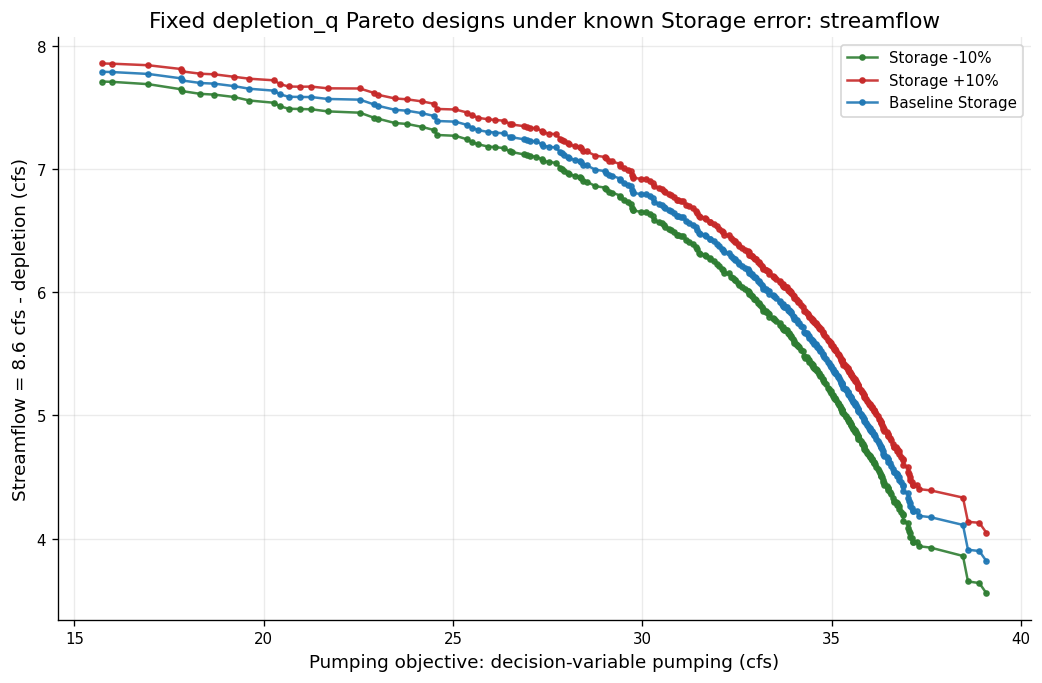

Saved figure: /workspaces/LPR_redux/LPR_pycap_opt/notebooks/Uncertainty_Project_depletion_q/project_output/301a_individual_parameter_known_error_depletion_q/storage/301a_storage_pumping_vs_streamflow_scenarios.png


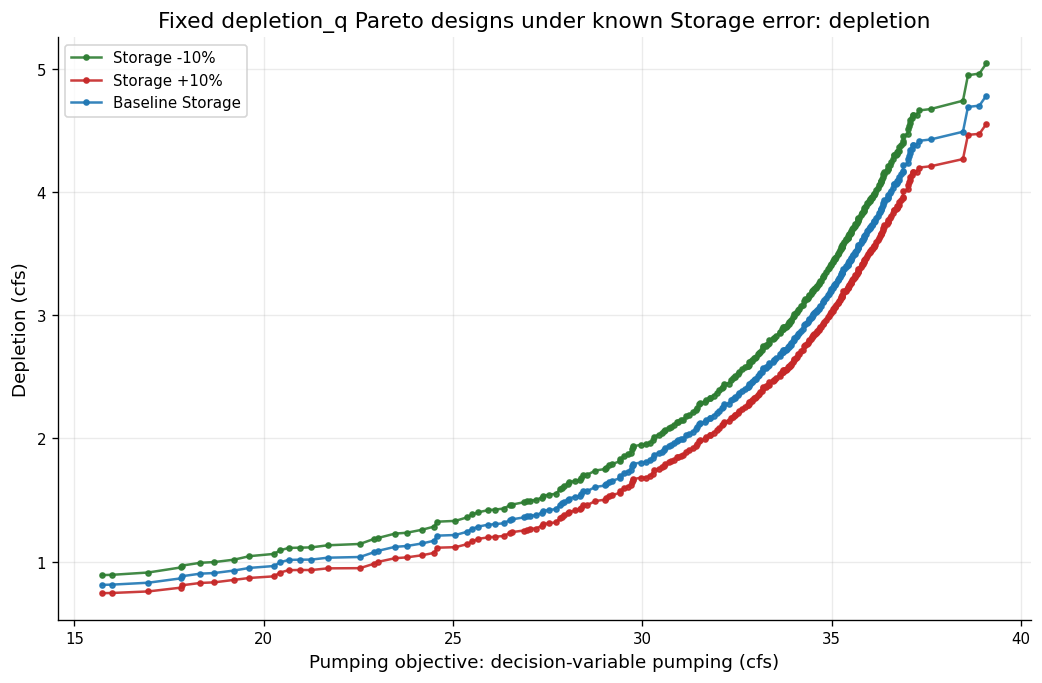

Saved figure: /workspaces/LPR_redux/LPR_pycap_opt/notebooks/Uncertainty_Project_depletion_q/project_output/301a_individual_parameter_known_error_depletion_q/storage/301a_storage_pumping_vs_depletion_scenarios.png


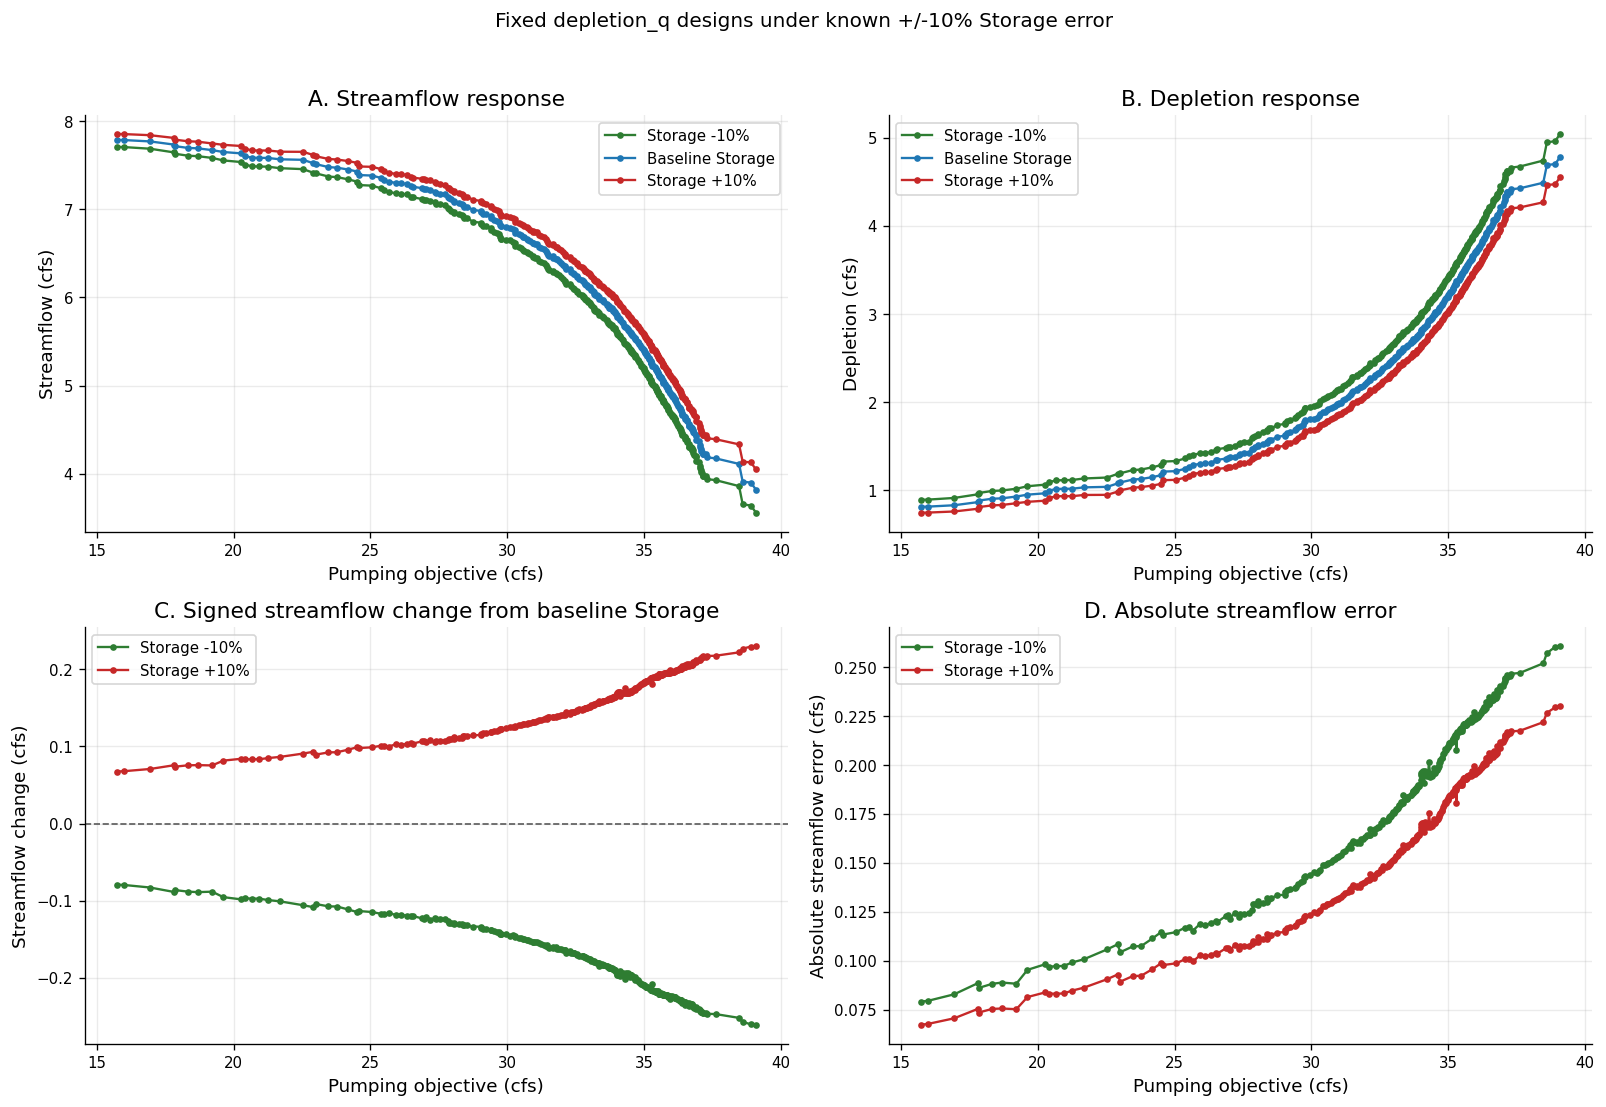

Saved figure: /workspaces/LPR_redux/LPR_pycap_opt/notebooks/Uncertainty_Project_depletion_q/project_output/301a_individual_parameter_known_error_depletion_q/storage/301a_storage_known_error_summary_2x2.png
Saved streamflow scenario plot: /workspaces/LPR_redux/LPR_pycap_opt/notebooks/Uncertainty_Project_depletion_q/project_output/301a_individual_parameter_known_error_depletion_q/storage/301a_storage_pumping_vs_streamflow_scenarios.png
Saved depletion scenario plot: /workspaces/LPR_redux/LPR_pycap_opt/notebooks/Uncertainty_Project_depletion_q/project_output/301a_individual_parameter_known_error_depletion_q/storage/301a_storage_pumping_vs_depletion_scenarios.png
Saved 2x2 summary plot: /workspaces/LPR_redux/LPR_pycap_opt/notebooks/Uncertainty_Project_depletion_q/project_output/301a_individual_parameter_known_error_depletion_q/storage/301a_storage_known_error_summary_2x2.png


In [12]:
streamflow_fig = OUTPUT_DIR / f"301a_{PARAMETER_OUTPUT_TAG}_pumping_vs_streamflow_scenarios.png"
depletion_fig = OUTPUT_DIR / f"301a_{PARAMETER_OUTPUT_TAG}_pumping_vs_depletion_scenarios.png"
summary_fig = OUTPUT_DIR / f"301a_{PARAMETER_OUTPUT_TAG}_known_error_summary_2x2.png"

up.plot_depletion_q_known_parameter_fronts(
    results_long=results_long_with_errors,
    outfile=streamflow_fig,
    y_metric="streamflow",
    parameter_label=PARAMETER_LABEL,
)

up.plot_depletion_q_known_parameter_fronts(
    results_long=results_long_with_errors,
    outfile=depletion_fig,
    y_metric="depletion",
    parameter_label=PARAMETER_LABEL,
)

up.plot_depletion_q_known_parameter_error_2x2(
    wide=results_wide,
    outfile=summary_fig,
    scenario_order=scenario_order,
    parameter_label=PARAMETER_LABEL,
)

print("Saved streamflow scenario plot:", streamflow_fig)
print("Saved depletion scenario plot:", depletion_fig)
print("Saved 2x2 summary plot:", summary_fig)


## 6. Interpret the known parameter-error result

This short interpretation cell is meant as a quick sanity check after the full run.


In [13]:
baseline = scenario_summary.loc[scenario_summary["scenario"] == baseline_scenario].iloc[0]
minus_scenario = [s for s in scenario_order if s.endswith("minus_10pct")][0]
plus_scenario = [s for s in scenario_order if s.endswith("plus_10pct")][0]
minus = scenario_summary.loc[scenario_summary["scenario"] == minus_scenario].iloc[0]
plus = scenario_summary.loc[scenario_summary["scenario"] == plus_scenario].iloc[0]

print("Baseline mean streamflow (cfs):", baseline["mean_streamflow_cfs"])
print(PARAMETER_LABEL, "-10% mean streamflow change from baseline (cfs):", minus["mean_streamflow_change_from_baseline_cfs"])
print(PARAMETER_LABEL, "+10% mean streamflow change from baseline (cfs):", plus["mean_streamflow_change_from_baseline_cfs"])
print("Baseline mean depletion (cfs):", baseline["mean_depletion_cfs"])
print(PARAMETER_LABEL, "-10% mean depletion change from baseline (cfs):", minus["mean_depletion_change_from_baseline_cfs"])
print(PARAMETER_LABEL, "+10% mean depletion change from baseline (cfs):", plus["mean_depletion_change_from_baseline_cfs"])

if abs(plus["mean_streamflow_change_from_baseline_cfs"]) < 1e-8 and abs(minus["mean_streamflow_change_from_baseline_cfs"]) < 1e-8:
    print("Interpretation: this parameter produced little to no mean streamflow response for the tested +/-10% range.")
else:
    print("Interpretation: this parameter produced a measurable streamflow response for the fixed depletion_q designs.")


Baseline mean streamflow (cfs): 5.851079481942212
Storage -10% mean streamflow change from baseline (cfs): -0.18401402415730894
Storage +10% mean streamflow change from baseline (cfs): 0.1599902090495342
Baseline mean depletion (cfs): 2.7489205180577874
Storage -10% mean depletion change from baseline (cfs): 0.18401402415730894
Storage +10% mean depletion change from baseline (cfs): -0.15999020904953415
Interpretation: this parameter produced a measurable streamflow response for the fixed depletion_q designs.


## 7. List final outputs

In [14]:
for path in sorted(OUTPUT_DIR.glob("*")):
    print(path.name)


301a_storage_known_error_summary_2x2.png
301a_storage_pumping_vs_depletion_scenarios.png
301a_storage_pumping_vs_streamflow_scenarios.png
301a_storage_scenario_reevaluation_long.csv
301a_storage_scenario_reevaluation_wide.csv
301a_storage_scenario_summary.csv
